In [196]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# IMPORT LIBRARY 

In [197]:
df=pd.read_csv(r"C:\Users\mosa\Downloads\insurance.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# Exploratory Data Analysis (EDA)

In [198]:
print("=" * 50)
print("DATASET SHAPE")
print("=" * 50)
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print("=" * 50)

print("\n")

print("=" * 50)
print("DUPLICAT DATA")
print("=" * 50)
print(df[df.duplicated(keep=False)])
print(f"number of duplicate: {df.duplicated().sum()}\n")

print("\n")

print("=" * 50)
print("SHOW 5 ROW")
print("=" * 50)
print(df.head())

print("\n")

print("=" * 50)
print("DATA TYPES")
print("=" * 50)
print(df.dtypes)

print("\n")

print("="*50)
print("DATA INFO")
print("="*50)
df.info()

print("\n")

print("="*50)
print("MISSING VALUES")
print("="*50)
print(df.isnull().sum())

print("\n")

print("="*50)
print("NUMERICAL SUMMARY")
print("="*50)
print(df.describe())

print("\n")

print("="*50)
print("NUMERICAL SUMMARY")
print("="*50)
print(df.describe(include='object'))

DATASET SHAPE
Rows: 1338
Columns: 7


DUPLICAT DATA
     age   sex    bmi  children smoker     region    charges
195   19  male  30.59         0     no  northwest  1639.5631
581   19  male  30.59         0     no  northwest  1639.5631
number of duplicate: 1



SHOW 5 ROW
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


DATA TYPES
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


DATA INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    -----

# UNIQE VARAIBLE IN COLUM

In [199]:
numerical_col=df.select_dtypes(include=["int64","float64"]).columns.tolist()
catigorical_col=df.select_dtypes(include="object").columns.tolist()

for col in catigorical_col:
    print(f"-----{col}-----")
    print(f"Unique values in column: {df[col].unique()}")
    print(f"number of unique value: {df[col].nunique()}")
    print("--------------------------------")
    print("\n")

-----sex-----
Unique values in column: ['female' 'male']
number of unique value: 2
--------------------------------


-----smoker-----
Unique values in column: ['yes' 'no']
number of unique value: 2
--------------------------------


-----region-----
Unique values in column: ['southwest' 'southeast' 'northwest' 'northeast']
number of unique value: 4
--------------------------------




# DROP DUPLICATE

In [200]:
df=df.drop_duplicates()

In [201]:
df.duplicated().sum()

0

# VISULIZATION NUMERICAL 

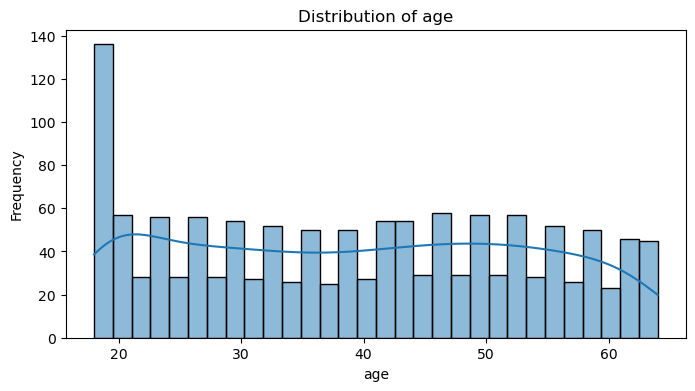

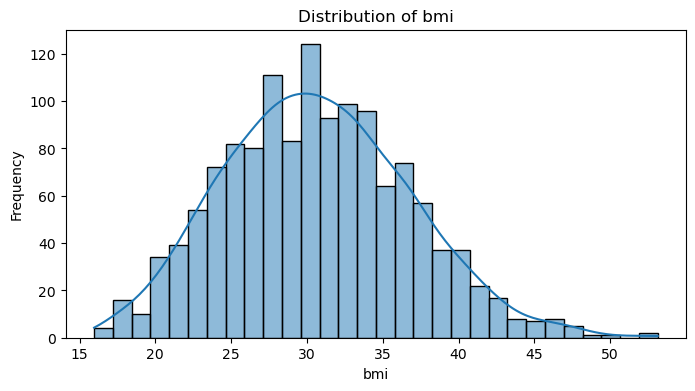

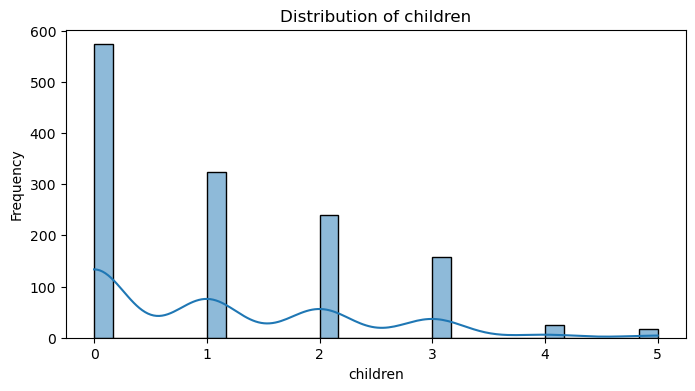

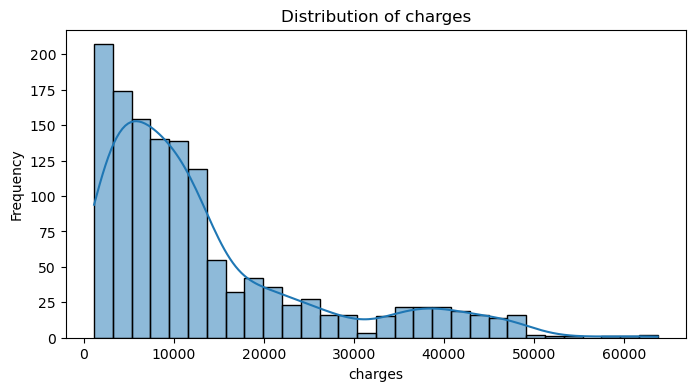

In [202]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in numerical_col:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

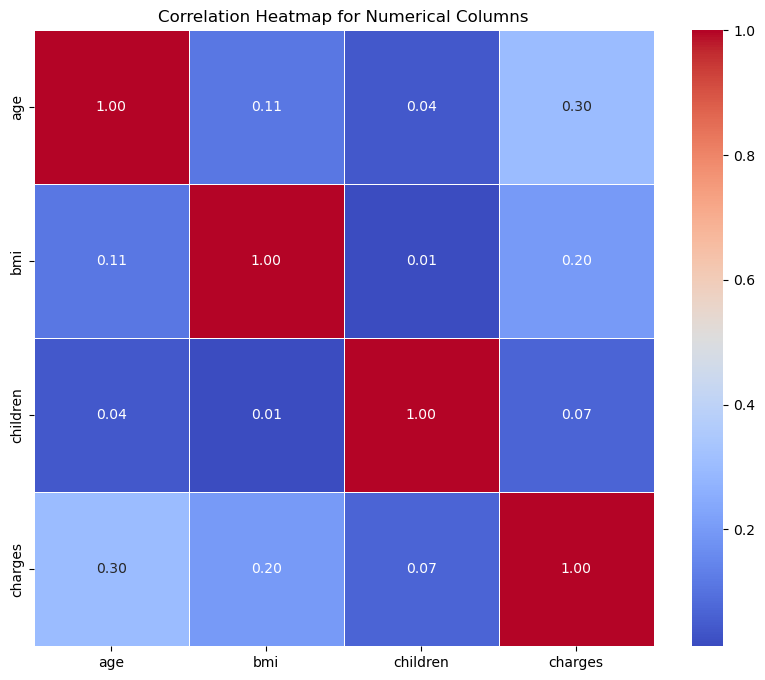

In [203]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_col].corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap for Numerical Columns")
plt.show()

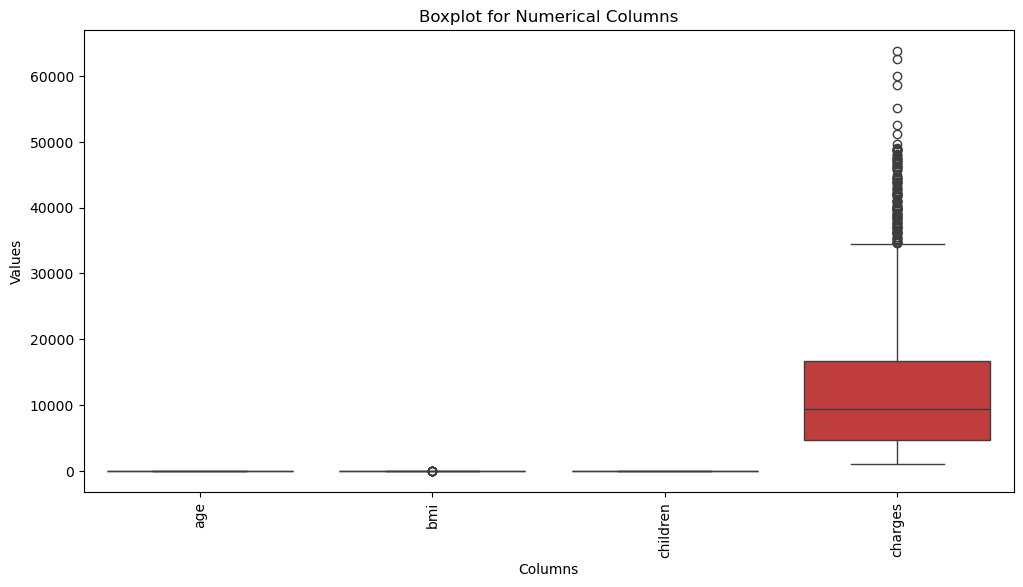

In [204]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numerical_col])
plt.xticks(rotation=90)
plt.title("Boxplot for Numerical Columns")
plt.xlabel("Columns")
plt.ylabel("Values")
plt.show()

# VISUALIZATION CATEGORICAL 

In [205]:
print(catigorical_col)

['sex', 'smoker', 'region']


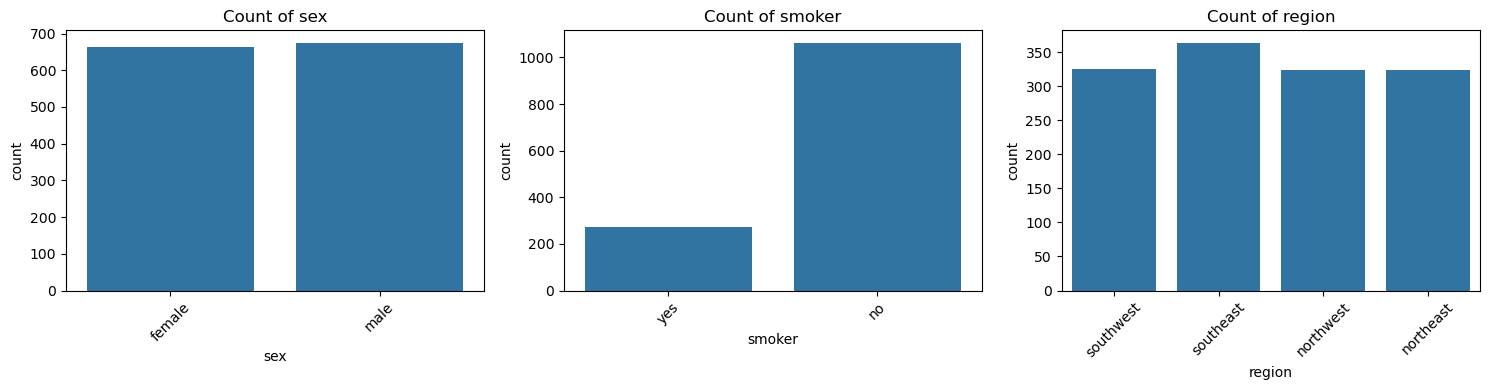

In [206]:
plt.figure(figsize=(15, 4))
for i, col in enumerate(catigorical_col, 1):
    plt.subplot(1, 3, i)
    sns.countplot(data=df, x=col)
    plt.title(f"Count of {col}")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

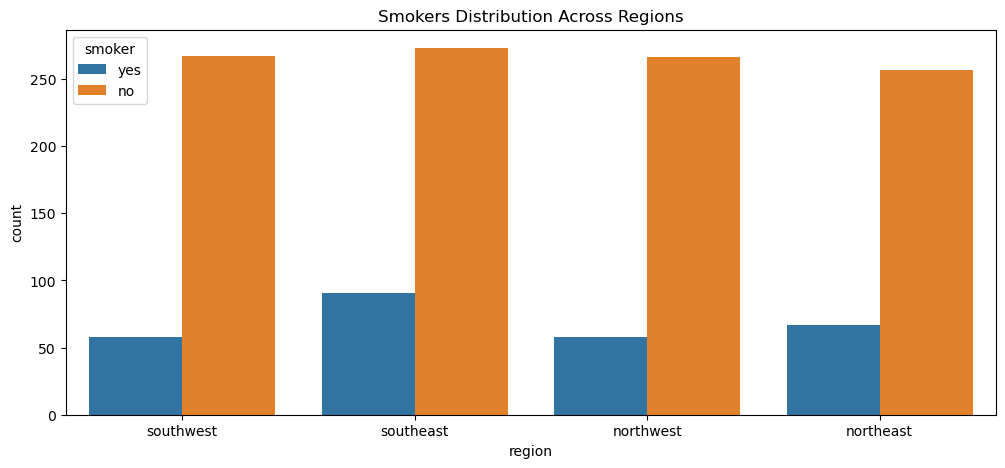

In [207]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='region', hue='smoker')
plt.title("Smokers Distribution Across Regions")
plt.show()

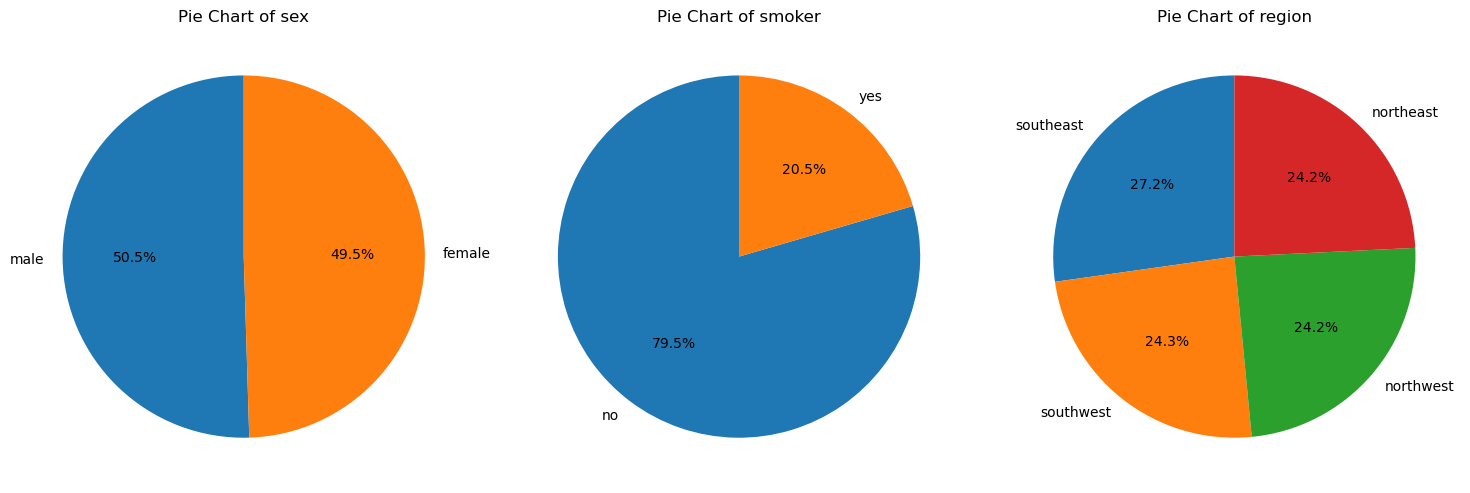

In [208]:


plt.figure(figsize=(15, 5))
for i, col in enumerate(catigorical_col, 1):
    plt.subplot(1, 3, i)
    counts = df[col].value_counts()
    plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90)
    plt.title(f"Pie Chart of {col}")

plt.tight_layout()
plt.show()

# ENCODING FOR CATEGORICAL COLUM 

In [209]:
df['sex'] = df['sex'].map({'female': 0, 'male': 1})
df['smoker'] = df['smoker'].map({'no': 0, 'yes': 1})

C:\Users\mosa\AppData\Local\Temp\ipykernel_2392\4282671281.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sex'] = df['sex'].map({'female': 0, 'male': 1})
C:\Users\mosa\AppData\Local\Temp\ipykernel_2392\4282671281.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['smoker'] = df['smoker'].map({'no': 0, 'yes': 1})


In [210]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,northwest,10600.54830
1334,18,0,31.920,0,0,northeast,2205.98080
1335,18,0,36.850,0,0,southeast,1629.83350
1336,21,0,25.800,0,0,southwest,2007.94500


In [211]:
df = pd.get_dummies(df, columns=['region'], drop_first=True, dtype=int)

# DETECT OUTLIERS

In [212]:
outliers_column = ["age", "charges", "bmi"]

print('\n--- Outliers Capping Process ---')

for column in outliers_column:
    lower_bound = df[column].quantile(0.05)
    upper_bound = df[column].quantile(0.95)

    before_count = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()
    
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
    
    after_count = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()

    print(f'{column} -> Before: {before_count} | After: {after_count}')


--- Outliers Capping Process ---
age -> Before: 45 | After: 0
charges -> Before: 134 | After: 0
bmi -> Before: 134 | After: 0


In [213]:
df

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1767.49292,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,10600.54830,1,0,0
1334,18,0,31.920,0,0,2205.98080,0,0,0
1335,18,0,36.850,0,0,1767.49292,0,1,0
1336,21,0,25.800,0,0,2007.94500,0,0,1


# SPLITE DATA

In [214]:
x = df.drop("charges", axis=1)
y = df["charges"]

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [215]:
print(f"Shape train: {x_train.shape}")
print(f"Shape test: {x_test.shape}")

Shape train: (1069, 8)
Shape test: (268, 8)


# SCALING FROM NUMERICAL COLUMN 

In [216]:
scaler=StandardScaler()
cols_to_scale = ['age', 'bmi', 'children']

x_train[cols_to_scale] = scaler.fit_transform(x_train[cols_to_scale])
x_test[cols_to_scale] = scaler.transform(x_test[cols_to_scale])

x_train

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
1114,-1.161181,1,-1.076057,-0.907908,0,0,0,0
968,-1.305000,1,-0.853955,0.766904,0,0,0,0
599,0.924195,0,1.264559,0.766904,0,1,0,0
170,1.643291,1,1.908925,-0.907908,0,0,1,0
275,0.564648,0,-0.700192,0.766904,0,0,0,0
...,...,...,...,...,...,...,...,...
1096,0.852286,0,0.803269,0.766904,1,0,0,0
1131,-0.873543,1,1.908925,0.766904,0,0,0,1
1295,-1.376909,1,-1.527456,-0.070502,0,0,0,1
861,-0.082538,0,-0.448416,1.604310,0,0,0,1
